In [67]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import numpy as np
from shapely.geometry import Polygon, Point
import os
from collections import Counter
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim

Q1. Spatial Reasoning & Data Filtering

In [ ]:
gdf = gpd.read_file("Dataset_Delhi_NCR/delhi_ncr_region.geojson")
gdf_delhi = gdf.to_crs(epsg=32644)

In [69]:
gdf_delhi

,geometry
0,"POLYGON ((681647.35 3123088.65, 681757.14 3123..."
1,"POLYGON ((709716.57 3242533.024, 709810.153 32..."
2,"MULTIPOLYGON (((705455 3018827, 705708.5 30187..."
3,"POLYGON ((790220.498 3179588.253, 790236.508 3..."
4,"POLYGON ((716145.844 3186203.817, 716234.798 3..."
5,"POLYGON ((733689.111 3169857.212, 733742.319 3..."
6,"POLYGON ((739514.346 3202273.305, 739688.189 3..."
7,"POLYGON ((797704.502 3198879.876, 797815.577 3..."
8,"POLYGON ((752411.13 3239248.982, 752435.68 323..."
9,"POLYGON ((784468.079 3290486.55, 784529.618 32..."


In [70]:
grid_size = 60000 #in meter - 60km
xmin,ymin,xmax,ymax = gdf_delhi.total_bounds



In [71]:
grid_polys = []
for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        square = Polygon([
            (x, y), 
            (x + grid_size, y), 
            (x + grid_size, y + grid_size), 
            (x, y + grid_size)
        ])
        grid_polys.append(square)

In [72]:
mesh_gdf = gpd.GeoDataFrame(geometry=grid_polys , crs="EPSG:32643")

In [73]:
len(mesh_gdf)

35

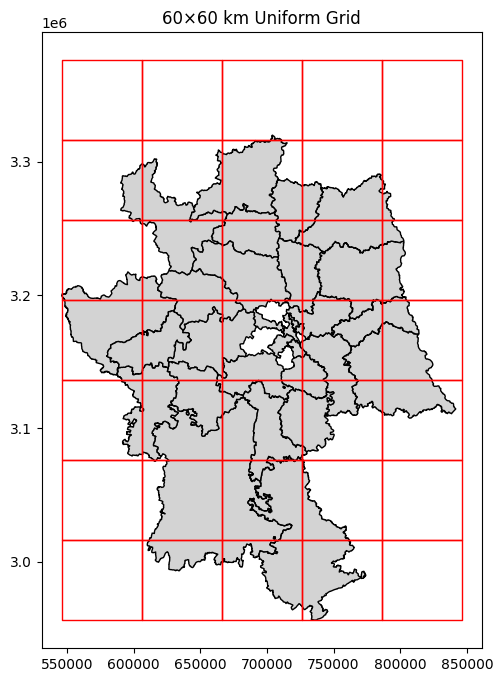

In [74]:
fig, ax = plt.subplots(figsize=(8,8))
gdf_delhi.plot(ax=ax, color="lightgrey", edgecolor="black")
mesh_gdf.plot(ax=ax, facecolor="none", edgecolor="red")

plt.title("60×60 km Uniform Grid")
plt.show()

In [75]:

image_list = os.listdir("Dataset_Delhi_NCR/rgb") 

total_before = len(image_list)


boundary = gpd.read_file('Dataset_Delhi_NCR/delhi_ncr_region.geojson') #in degree

filtered_images = []
Center_cords = []

for name in image_list:
    try:
        
        clean_name = name.replace(".png", "")
        parts = clean_name.split('_') # '_' speartes the latitude from the longitude

        lat = float(parts[0])
        lon = float(parts[1])
        
        if boundary.contains(Point(lon,lat)).any():
            filtered_images.append(name)
            Center_cords.append(Point(lon,lat))
    except:
        continue

total_after = len(filtered_images)

In [76]:
#Total number of Images Before and After
print(f"Total Before {total_before} & Total After {total_after}")

Total Before 9216 & Total After 8015


In [77]:
Center_cords

[<POINT (76.856 28.206)>,
 <POINT (76.865 28.206)>,
 <POINT (76.873 28.206)>,
 <POINT (76.882 28.206)>,
 <POINT (76.891 28.206)>,
 <POINT (76.894 28.206)>,
 <POINT (76.906 28.206)>,
 <POINT (76.914 28.206)>,
 <POINT (76.923 28.206)>,
 <POINT (76.932 28.206)>,
 <POINT (76.941 28.206)>,
 <POINT (76.944 28.206)>,
 <POINT (76.956 28.206)>,
 <POINT (76.965 28.206)>,
 <POINT (76.973 28.206)>,
 <POINT (76.982 28.206)>,
 <POINT (76.991 28.206)>,
 <POINT (76.994 28.206)>,
 <POINT (77.006 28.206)>,
 <POINT (77.015 28.206)>,
 <POINT (77.023 28.206)>,
 <POINT (77.032 28.206)>,
 <POINT (77.041 28.206)>,
 <POINT (77.044 28.206)>,
 <POINT (77.056 28.206)>,
 <POINT (77.064 28.206)>,
 <POINT (77.073 28.206)>,
 <POINT (77.082 28.206)>,
 <POINT (77.091 28.206)>,
 <POINT (77.094 28.206)>,
 <POINT (77.106 28.206)>,
 <POINT (77.115 28.206)>,
 <POINT (77.123 28.206)>,
 <POINT (77.132 28.206)>,
 <POINT (77.141 28.206)>,
 <POINT (77.144 28.206)>,
 <POINT (77.156 28.206)>,
 <POINT (77.164 28.206)>,
 <POINT (77.

In [78]:
import rasterio
from rasterio.windows import Window
valid_images = os.listdir("Dataset_Delhi_NCR/rgb") 

landcover = rasterio.open("Dataset_Delhi_NCR/worldcover_bbox_delhi_ncr_2021.tif")

patches = []
labels= []

for img in valid_images:
    lat, lon = map(float, img.replace(".png","").split("_"))

    # raster pixel
    row, col = landcover.index(lon, lat)

    # extract 128x128 patch
    window = Window( col-64, row-64, 128, 128)
    patch = landcover.read(1, window=window)
    patches.append(patch)
    

    unique_classes, counts = np.unique(patch, return_counts=True) 
    
    max_count_index = np.argmax(counts) 

    dominant_class = unique_classes[max_count_index]

    labels.append(dominant_class)

print( {len(labels)} )
   

{9216}


In [79]:
esa_to_label = {
    10: "Tree_cover",         # 10
    20: "Shrubland",          # 20
    30: "Grassland",          # 30
    40: "Cropland",           # 40
    50: "Built-up",           # 50
    60: "Bare_sparse_veg",    # 60
    70: "Snow_ice",           # 70
    80: "Water",              # 80
    90: "Herbaceous_wetland", # 90
    95: "Mangroves",          # 95
    100: "Other",             # 100 or unknown -> 'Other'
}

In [80]:
simplified_labels = []
for label in labels:

    clean_text = esa_to_label.get(label, 'Others')
    
    simplified_labels.append(clean_text)
print("codes  ", labels[:10])
print("categories  ", simplified_labels[:10])

codes   [np.uint8(50), np.uint8(50), np.uint8(50), np.uint8(50), np.uint8(40), np.uint8(40), np.uint8(40), np.uint8(40), np.uint8(40), np.uint8(40)]
categories   ['Built-up', 'Built-up', 'Built-up', 'Built-up', 'Cropland', 'Cropland', 'Cropland', 'Cropland', 'Cropland', 'Cropland']


In [81]:
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train,y_test = train_test_split(valid_images ,simplified_labels , test_size=0.4 , random_state= 42 )

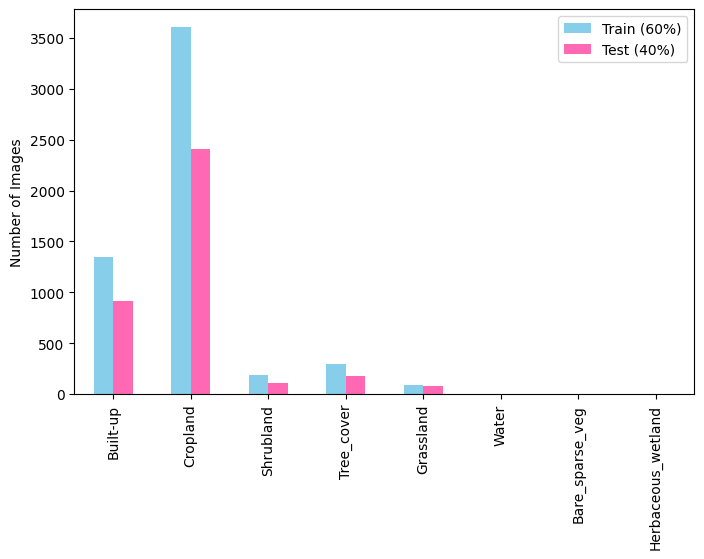

In [82]:
df = pd.DataFrame({'Train (60%)': Counter(y_train), 'Test (40%)': Counter(y_test)})

df.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'hotpink'])

plt.ylabel('Number of Images')
plt.show()

In [83]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

category_to_id = {
    # Vegetation ID1
    "Tree_cover": 1,         
    "Shrubland": 1,          
    "Grassland": 1,          
    
    # Cropland  ID3
    "Cropland": 3,           
    
    # Built-up  ID0
    "Built-up": 0,           
    
    # Water  ID2
    "Water": 2,              
    
    # Others ID4
    "Bare_sparse_veg": 4,    
    "Snow_ice": 4,           
    "Herbaceous_wetland": 4, 
    "Mangroves": 4,          
    "Other": 4               
}

image_transforms = transforms.Compose([
    transforms.ToTensor() 
])

In [88]:
class DelhiLandCoverDataset(Dataset):
    def __init__(self, image_filenames, labels, image_dir, transform):

        self.image_filenames = image_filenames
        self.labels = labels
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        label_text = self.labels[idx]
        img_path = os.path.join(self.image_dir, img_name)
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        label_id = category_to_id[label_text]

        return image, label_id

In [89]:
rgb_folder_path = "Dataset_Delhi_NCR/rgb"

train_dataset = DelhiLandCoverDataset(X_train, y_train, rgb_folder_path, transform=image_transforms)
test_dataset = DelhiLandCoverDataset(X_test, y_test, rgb_folder_path, transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  #using pretrained resnet

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)


In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train() 
    total_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                
        predictions = model(images)           
        loss = criterion(predictions, labels) 
        loss.backward()                       
        optimizer.step()                      
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    
    model.eval() 
    correct = 0
    total = 0
        
    with torch.no_grad(): 
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                
                guesses = torch.argmax(outputs, dim=1)

                correct += (guesses == labels).sum().item()
                total += len(labels) 
                

    accuracy = (correct / total) * 100
    print(f"Epoch {epoch+1}/{epochs} | Test Accuracy: {accuracy:.2f}%")